In [2]:
# using Pkg; Pkg.instantiate() # if error, resets config; delete Manifest.toml first, then run this code
using Revise
using Printf
using LinearAlgebra
using PyPlot
using FFTW
using MultiModeNoise

# Setting up initial conditions

In [3]:
λ0 = 1550e-9 # m
M = 3 # number of sp modes
Nt = 2^8 # 2^10, frequency bins
time_window = 25 # ps, range of pulse
β_order = 2; # mode order: 0, 1, 2, ...

# simulation params
sim = MultiModeNoise.get_disp_sim_params(λ0, M, Nt, time_window, β_order); # sim = dictionary of params from inputs from helpers.jl

L_fiber = 1 # m
radius = 62.5/2 # micron
core_NA = 0.275
alpha = 2.08 # GRIN fiber parabola param.
nx = 200 # spatial dir resolution
fiber_fname = @sprintf("../fibers/DispersiveFiber_GRIN_r=%.2f_M=%d_λ0=%.2fum_Nt=%d_time_window=%.2fps_nx=%d_Nbeta=%d.npz", radius, M, 1e6*λ0,
    Nt, time_window, nx, β_order+1)

# fiber params
fiber = MultiModeNoise.get_disp_fiber_params(L_fiber, radius, core_NA, alpha, nx, sim, fiber_fname);

fiber["zsave"] = LinRange(0, L_fiber, 101); # resolution in z, =linspace(start,stop,length) but lazy until collected
# fiber["zsave"] = LinRange(0, L_fiber, 11);
# fiber["zsave"] = nothing # no propagation results save in the mid points

P_cont = 0.25 # W
pulse_fwhm = 200e-15 # s
pulse_rep_rate = 80e6 # Hz

# u0_modes = normalize([0.4, 0.1, 0.0])
# u0_modes = normalize([0.01, 0.5, 0.5])
u0_modes = normalize([1, -7, 2])
u0_modes = normalize([0.3047514842181003 - 0.1212176801553783im, -0.19527485778306808 - 0.17258465757219718im, 0.1257224577684066 + 0.24229927029558837im]) # from running Michael's cw optimization code
println(abs2.(u0_modes)) # print new line, element-wise abs^2

ut0, uω0 = MultiModeNoise.get_initial_state(u0_modes, P_cont, pulse_fwhm, pulse_rep_rate, "sech_sq", sim); # initial state [Nt x M]

Load fiber params
[0.43026877246154643, 0.2716709364460401, 0.2980602910924135]


# Fiber propagation through L

In [4]:
@time sol_disp_mmf = MultiModeNoise.solve_disp_mmf(uω0, fiber, sim); # sol_disp_mmf = dictionary of solutions (uw, μw, νw), in simulate_mmf.jl

 10.239694 seconds (40.63 M allocations: 3.486 GiB, 4.06% gc time, 91.08% compilation time: <1% of which was recompilation)


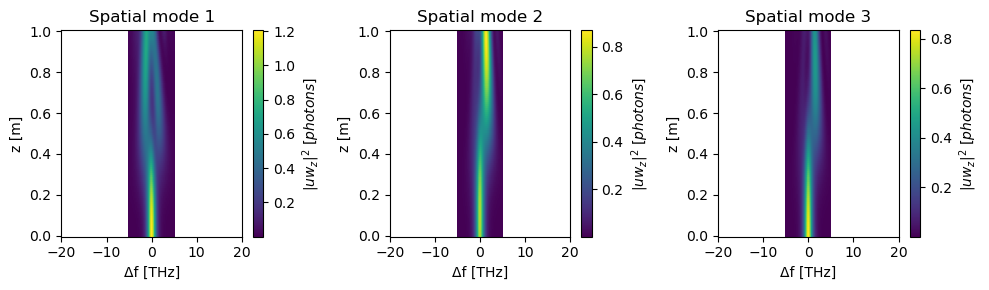

In [5]:
uω_z = sol_disp_mmf["uω_z"]; # uω_z = [L x Nt x M] = [fiber length, time point, spatial modes]

FF, ZZ = MultiModeNoise.meshgrid(sim["fs"] .- sim["f0"], fiber["zsave"]) # create meshgrid for plotting; fs: stop freq, f0: start freq (THz)

fig, axs = subplots(1, M, figsize=(10,3))
for i in 1:M 
    im = axs[i].pcolormesh(FF, ZZ, abs2.(fftshift(uω_z[:,:,i], 2)), shading="nearest") # plotting for every sp mode
    fig.colorbar(im, ax=axs[i], label=L"|uw_z|^2\ [photons]") # number of photons; photon-number-normalized power-like quantity (uw_z=sqrt(Nt*dt/hbar/omega0)*Aw_z); Aw_z = [sqrt(power)]
    axs[i].set_title(@sprintf("Spatial mode %d",i))
    axs[i].set_xlim(-20,20)
    axs[i].set_xlabel("Δf [THz]")
    axs[i].set_ylabel("z [m]")
end
fig.tight_layout()

normalize the above color scheme with $\epsilon$ and $N_t$ properly: $u_w(z)\times\sqrt{N_t\epsilon}$

# Spatial-mode-dependent noise value (frequency summed)

In [6]:
∂Xkl∂u = zeros(ComplexF64, M, M, Nt, M)

for k in 1:M
    λωL = 2 * uω_z[end,:,k] * diagm(ones(M))[:,k]'
    sol_adjoint_disp_mmf = MultiModeNoise.solve_adjoint_disp_mmf(λωL, sol_disp_mmf["ode_sol"], fiber, sim)
    ∂Xkl∂u[k,k,:,:] = -0.5*sqrt(sim["ε"]*Nt)*conj.(sol_adjoint_disp_mmf(0))

    print(@sprintf("\rprogress: %d/%d", k, M)); flush(stdout)
end

##### spatial-mode-dependent noise calculation #####
using Tullio  # tullio from Einstein sum notation using Tullio Levi-Civita's Levi Civita ϵ_ijk symbol

ε = sim["ε"] # Δt/(ħω0)
U = u0_modes # mode composition at start z = 0, e.g., [0.5,0.5,0]
# δF_in_ω = abs2.(uω0[:,1]) ./ maximum(abs2.(uω0[:,1])) * (1e3-1) # why this? = δF_in_ω=999 * max-normalized for spatial-mode #1
δF_in_ω = zeros(Float64, Nt) # no noise for input laser = shot-noise-limited
# δF_in_ω = ones(Float64, Nt) # thermal source
uωf = uω_z[end,:,:]; # cf., uω_z = [L, Nt, M]
F = zeros(Float64, M)

# noise plotting for mode m
for m in 1:M # spatial mode #, m ∈ [1, M]
    uωf_m = uωf[:,m] # intensity for mode m
    @tullio X = Nt * ε * abs2.(uωf_m[ω]) # X = n = number of photons = photon-number normalized |electric field|^2
    # @tullio X = Nt * ε * conj(uωf_m[ω]) * uωf_m[ω]
    ∂Xmm∂u = ∂Xkl∂u[m,m,:,:]
    var_X = MultiModeNoise.compute_noise_map_modem_fsum(X, ∂Xmm∂u, U, δF_in_ω); # var_X = noise = (Δn)^2
    F[m] = MultiModeNoise.lin_to_dB.(var_X./X)
end
F

progress: 3/3

3-element Vector{Float64}:
 0.67027110142551
 2.8715460483186717
 3.047859740450365

In [7]:
sum(F)

6.589676890194546

# Multi-pixel noise after propagation

In [ ]:
using Tullio

ϕ = fiber["ϕ"] # spatial mode
ε = sim["ε"] # Δt/(ħω0)
U = u0_modes # mode composition at start z = 0, e.g., [0.5,0.5,0]
δF_in_ω = abs2.(uω0[:,1]) ./ maximum(abs2.(uω0[:,1])) * (1e3-1)
uωf = uω_z[end,:,:]; # cf., uω_z = [L, Nt, M]

# noise plotting

@tullio X[i] := ϕ[i,k] * ϕ[i,l] * conj(uωf[ω,k]) * uωf[ω,l]
X = Nt * ε * real.(X)
var_X = MultiModeNoise.compute_noise_map(X, ∂Xkl∂u, U, ϕ, δF_in_ω); # noise = (Δn)^2

MultiModeNoise.plot_fiber(fiber["x"], MultiModeNoise.lin_to_dB.(reshape(var_X, (nx, nx))), radius, radius, vmin=60)

In [ ]:
MultiModeNoise.plot_fiber(fiber["x"], MultiModeNoise.lin_to_dB.(reshape(var_X, (nx, nx))), radius, radius, vmin=-10, vmax=0, cbarlabel="noise [dB]")

In [ ]:
pcolormesh(reshape(var_X,(nx,nx)),shading="nearest")

# Single-pixel intensity after propagation

In [ ]:
# sol_disp_mmf = MultiModeNoise.solve_disp_mmf(uω0, fiber, sim);

# single pixel (= single-px noise)
XX, YY = MultiModeNoise.meshgrid(fiber["x"], fiber["x"])
ϕ_pix = fiber["ϕ"][argmin(vec((XX .- 5).^2 + (YY .- 5).^2)),:]; # center pixel ϕ_pix value = index of the smallest radius in XX-YY meshgrid; ϕ = [nx^2 x M] matrix for M spatial modes
λωL = 2 * ((uω_z[end,:,:] * ϕ_pix) * ϕ_pix'); # electric field value = 2*u*|phi|^2 at z = L (=end), x,y = center w/ ...

sol_adjoint_disp_mmf = MultiModeNoise.solve_adjoint_disp_mmf(λωL, sol_disp_mmf["ode_sol"], fiber, sim);

fig, axs = subplots(1, M, figsize=(13,3))
for i in 1:M
    axs[i].set_title(@sprintf("Spatial mode %d",i))
    axs[i].plot((sim["fs"] .- sim["f0"]), abs2.(fftshift(sol_adjoint_disp_mmf(0)[:,i])), "x-", lw=0.8, label="Adjoint") # sol_...(0) = [λ_ωL x M] solutions at time 0; sol_...(fiber["L"]) = solutions at time 1, after L-length propagation
    axs[i].set_xlim(-5,5)
    axs[i].set_xlabel("Δf [THz]")
    axs[i].set_ylabel("Intensity [?]") # [unit of λ_ωL]? Sensitivity? [dB]
    axs[i].legend()
end
fig.tight_layout()

# Multi-pixel intensity after propagation

In [ ]:
# all pixels (= multi-px noise = camera image)
∂Xkl∂u = zeros(ComplexF64, M, M, Nt, M)

for k in 1:M
    for l in 1:M
        λωL = 2 * uω_z[end,:,l] * diagm(ones(M))[:,k]'
        sol_adjoint_disp_mmf = MultiModeNoise.solve_adjoint_disp_mmf(λωL, sol_disp_mmf["ode_sol"], fiber, sim)
        ∂Xkl∂u[k,l,:,:] = -0.5*sqrt(sim["ε"]*Nt)*conj.(sol_adjoint_disp_mmf(0))

        print(@sprintf("\rprogress: %d/%d, %d/%d", k, M, l, M)); flush(stdout)
    end
end

using Tullio  # tullio from Einstein sum notation using Tullio Levi-Civita's Levi Civita ϵ_ijk symbol

ϕ = fiber["ϕ"] # spatial mode; ϕ = [nx^2 x M] matrix for M spatial modes
ε = sim["ε"] # Δt/(ħω0)
U = u0_modes # mode composition at start z = 0, e.g., [0.5,0.5,0]
δF_in_ω = abs2.(uω0[:,1]) ./ maximum(abs2.(uω0[:,1])) * (1e3-1)
uωf = uω_z[end,:,:]; # cf., uω_z = [L, Nt, M]

# noise plotting

@tullio X[i] := ϕ[i,k] * ϕ[i,l] * conj(uωf[ω,k]) * uωf[ω,l] # |electric field|^2 at pixel [i]
X = Nt * ε * real.(X) # X = n = number of photons = photon-number normalized |electric field|^2
var_X = MultiModeNoise.compute_noise_map(X, ∂Xkl∂u, U, ϕ, δF_in_ω); # var_X = noise = (Δn)^2

MultiModeNoise.plot_fiber(fiber["x"], MultiModeNoise.lin_to_dB.(reshape(var_X, (nx, nx))), radius, radius, vmin=60, vmax=100, cbarlabel="Noise [dB]") # in dB

# Spatial-mode-dependent noise (over all pixels)

In [ ]:
# # all pixels (= multi-px noise = camera image)
# ∂Xkl∂u = zeros(ComplexF64, M, M, Nt, M)

# for k in 1:M
#     for l in 1:M
#         λωL = 2 * uω_z[end,:,l] * diagm(ones(M))[:,k]'
#         sol_adjoint_disp_mmf = MultiModeNoise.solve_adjoint_disp_mmf(λωL, sol_disp_mmf["ode_sol"], fiber, sim)
#         ∂Xkl∂u[k,l,:,:] = -0.5*sqrt(sim["ε"]*Nt)*conj.(sol_adjoint_disp_mmf(0))

#         print(@sprintf("\rprogress: %d/%d, %d/%d", k, M, l, M)); flush(stdout)
#     end
# end

##### spatial-mode-dependent noise calculation #####
k = 1 # spatial mode #, k ∈ [1, M]
∂Xkk∂u = ∂Xkl∂u[k,k,:,:]

using Tullio  # tullio from Einstein sum notation using Tullio Levi-Civita's Levi Civita ϵ_ijk symbol

ϕ = fiber["ϕ"] # spatial mode; ϕ = [nx^2 x M] matrix for M spatial modes
ε = sim["ε"] # Δt/(ħω0)
U = u0_modes # mode composition at start z = 0, e.g., [0.5,0.5,0]
δF_in_ω = abs2.(uω0[:,1]) ./ maximum(abs2.(uω0[:,1])) * (1e3-1)
uωf = uω_z[end,:,:]; # cf., uω_z = [L, Nt, M]

# noise plotting for mode k
# in spatial-mode basis then, plot against frequency ω?

@tullio X[i] := ϕ[i,k] * ϕ[i,k] * conj(uωf[ω,k]) * uωf[ω,k] # |electric field|^2 at pixel [i]
X = Nt * ε * real.(X) # X = n = number of photons = photon-number normalized |electric field|^2
var_X = MultiModeNoise.compute_noise_map_modek(X, ∂Xkk∂u, U, ϕ, δF_in_ω); # var_X = noise = (Δn)^2

# MultiModeNoise.plot_fiber(fiber["x"], MultiModeNoise.lin_to_dB.(reshape(var_X, (nx, nx))), radius, radius, vmin=60, vmax=100, cbarlabel="Noise [dB]") # in dB
F = var_X./X
MultiModeNoise.plot_fiber(fiber["x"], MultiModeNoise.lin_to_dB.(reshape(F, (nx, nx))), radius, radius, vmin=nothing, vmax=nothing, cbarlabel=L"F=(Δn)^2/n\ [dB]")

In [ ]:
# MultiModeNoise.plot_fiber(fiber["x"], MultiModeNoise.lin_to_dB.(reshape(var_X, (nx, nx))), radius, radius; vmin=nothing, vmax=nothing, cbarlabel=L"(Δn)^2\ [dB]")
# MultiModeNoise.plot_fiber(fiber["x"], reshape(X, (nx, nx)), radius, radius, vmin=nothing, vmax=nothing, cbarlabel="n [photons]")

# F = var_X./X
# plot_fiber(fiber["x"], MultiModeNoise.lin_to_dB.(reshape(F, (nx, nx))), radius, radius, vmin=nothing, vmax=nothing, cbarlabel=L"F=(Δn)^2/n\ [dB]")

# fig, axs = subplots(1,2)
figure()
subplot(121)
# subplot(1,1)
plot(rand(2))
# axs[1].plot(rand(2))
# axs[2].plot(rand(3))
# axs[1].MultiModeNoise.plot_fiber(fiber["x"], MultiModeNoise.lin_to_dB.(reshape(var_X, (nx, nx))), radius, radius; vmin=nothing, vmax=nothing, cbarlabel=L"(Δn)^2 [dB]")
# axs[1].set_title(L"(Δn)^2")
# axs[2].MultiModeNoise.plot_fiber(fiber["x"], reshape(X, (nx, nx)), radius, radius, vmin=nothing, vmax=nothing, cbarlabel="n [photons]")
# axs[2].set_title(L"n")

# MultiModeNoise.plot_fiber(fiber["x"], MultiModeNoise.lin_to_dB.(reshape(var_X, (nx, nx))), radius, radius, vmin=60, vmax=100, cbarlabel="Noise [dB]") # in dB

# fig.tight_layout()

# Spatial-mode-dependent noise vs. frequency

In [ ]:
##### spatial-mode-dependent noise calculation #####
using Tullio  # tullio from Einstein sum notation using Tullio Levi-Civita's Levi Civita ϵ_ijk symbol

ϕ = fiber["ϕ"] # spatial mode; ϕ = [nx^2 x M] matrix for M spatial modes
ε = sim["ε"] # Δt/(ħω0)
U = u0_modes # mode composition at start z = 0, e.g., [0.5,0.5,0]
δF_in_ω = abs2.(uω0[:,1]) ./ maximum(abs2.(uω0[:,1])) * (1e3-1)
uωf = uω_z[end,:,:]; # cf., uω_z = [L, Nt, M]

# noise plotting for mode m
m = 1 # spatial mode #, m ∈ [1, M]
uωf_m = uωf[:,m] # intensity for mode m
X = Nt * ϵ * abs2.(uωf_m) # X = n = number of photons = photon-number normalized |electric field|^2

∂Xmm∂u = ∂Xkl∂u[m,m,:,:]

var_X = MultiModeNoise.compute_noise_map_modem(X, ∂Xmm∂u, U, ϕ, δF_in_ω); # var_X = noise = (Δn)^2
F = var_X./X

plot((sim["fs"] .- sim["f0"]), F, "x-", lw=0.8)
set_title(@sprintf("Spatial mode %d",m))
set_xlim(-5,5)
set_xlabel("Δf [THz]")
set_ylabel("F [dB]") # F = (Δn)^2/<n>
# axs[i].legend()
# MultiModeNoise.plot_fiber(fiber["x"], MultiModeNoise.lin_to_dB.(reshape(F, (nx, nx))), radius, radius, vmin=nothing, vmax=nothing, cbarlabel=L"F=(Δn)^2/n\ [dB]")

In [ ]:
abs2.(u0_modes)

In [ ]:
fiber

In [ ]:
ϕ_pix

In [ ]:
fiber["ϕ"]

In [ ]:
# fiber["L"]==1
sol_adjoint_disp_mmf(1)[:,1]==sol_adjoint_disp_mmf(fiber["L"])[:,1]

In [ ]:
# diagm(ones(M))[:,k]'
ones(3)
diagm([1,2,3])
diagm(ones(3))
diagm(ones(3)*im)[:,1]' # conjugate transpose